In [ ]:
import boto3
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

inspection_id = "0A1OLRVinference/evaluate_dent_arm_us_models_fhr8.ipynb96N3" #fhr7
angle_profiles = ["0"]
num_tracks = 22
run_number = 7
environment = "prod"


In [2]:
def download_s3_folder(bucket_name: str, s3_folder: str, local_dir: str = None):
    """
    Download the contents of a folder directory
    Args:
        bucket_name: the name of the s3 bucket
        s3_folder: the folder path in the s3 bucket
        local_dir: the dir data is downloaded to
    """
    s3 = boto3.resource("s3")
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=s3_folder):
        target = (
            obj.key
            if local_dir is None
            else os.path.join(local_dir, os.path.relpath(obj.key, s3_folder))
        )
        if not os.path.exists(os.path.dirname(target)):
            os.makedirs(os.path.dirname(target))
        if obj.key[-1] == "/":
            continue
        if not os.path.exists(target):
            bucket.download_file(obj.key, target)
            print("Downloading: {}".format(obj.key))

results_dir = f"./data-files/insp_{inspection_id}_dent_detection_ae"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
download_s3_folder("dv-ilit0007", f"track_runs/{inspection_id}/dent_detection_ae/", results_dir)


In [3]:
results_dir = f"./data-files/insp_{inspection_id}_dent_detection_ae"
root = Path(results_dir)
data_files = sorted(root.rglob("*.parquet"))

In [4]:
len(data_files), data_files

(37,
 [PosixPath('data-files/insp_0A1OLRV96N3_dent_detection_ae/distance_0000000000.0_0000001000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A1OLRV96N3_dent_detection_ae/distance_0000001000.0_0000002000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A1OLRV96N3_dent_detection_ae/distance_0000002000.0_0000003000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A1OLRV96N3_dent_detection_ae/distance_0000003000.0_0000004000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A1OLRV96N3_dent_detection_ae/distance_0000004000.0_0000005000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A1OLRV96N3_dent_detection_ae/distance_0000005000.0_0000006000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A1OLRV96N3_dent_detection_ae/distance_0000006000.0_0000007000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A1OLRV96N3_dent_detection_a

In [5]:
pd.read_csv(data_files[0])

,start,end,prob
0,-0.15,0.15,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,0.00,0.30,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,0.15,0.45,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,0.30,0.60,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,0.45,0.75,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...
6664,999.45,999.75,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6665,999.60,999.90,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6666,999.75,1000.05,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6667,999.90,1000.20,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [6]:
## Create a DataFrame for each profile and track and range
def create_df(frame_range=None):
    if frame_range is None:
        data_files_range = [f for f in data_files]
    else:
        data_files_range = [f for f in data_files if f.name.startswith(f"frames_{frame_range[0]:012d}_{frame_range[1]:012d}")]


    dfs = []
    for path in data_files_range:
        df = pd.read_csv(path)
        dfs.append(df)

        # Handle case where all DataFrames were empty or had errors
    if not dfs:
        print(f"No valid data found for frame_range={frame_range}")
        return pd.DataFrame()
    
    return pd.concat(dfs) if len(dfs) > 1 else dfs[0]

Threshold 0.4000: 53076/245848 passed (53076/245848 positives, 21.5889%)
Threshold 0.5000: 51377/245848 passed (51377/245848 positives, 20.8979%)
Threshold 0.6000: 49674/245848 passed (49674/245848 positives, 20.2052%)
Threshold 0.7000: 47697/245848 passed (47697/245848 positives, 19.4010%)
Threshold 0.8000: 45295/245848 passed (45295/245848 positives, 18.4240%)
Threshold 0.9000: 41478/245848 passed (41478/245848 positives, 16.8714%)
Threshold 0.9700: 34907/245848 passed (34907/245848 positives, 14.1986%)
Threshold 0.9900: 28126/245848 passed (28126/245848 positives, 11.4404%)


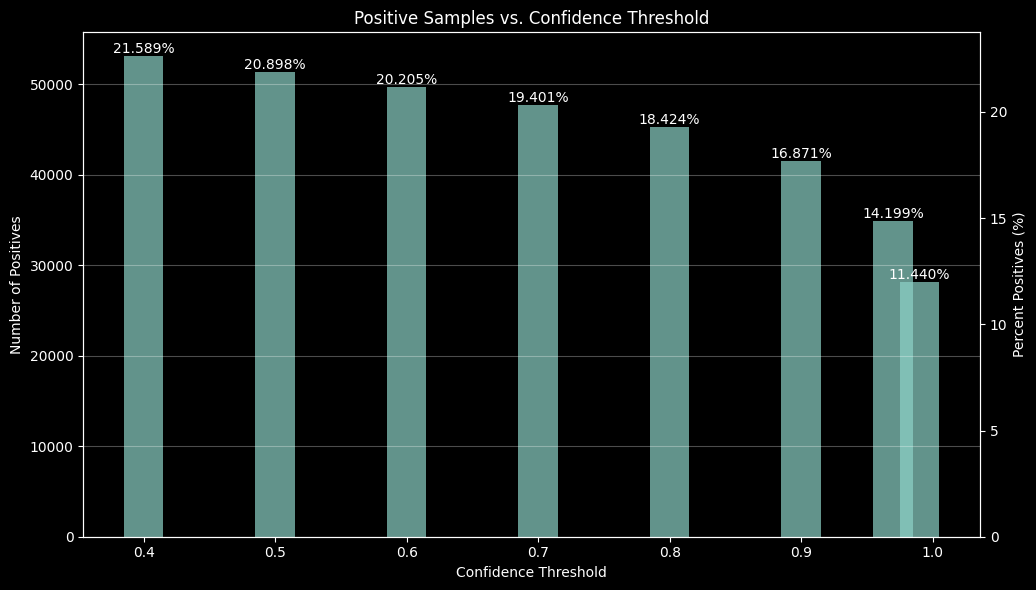

In [7]:
# Assuming all_dfs is your dataframe with columns: start, end, and prob
import ast

# Function to parse probability strings into actual lists if needed
def parse_prob(prob_str):
    """Convert string representation of list to actual list if needed"""
    if isinstance(prob_str, str):
        try:
            return ast.literal_eval(prob_str)
        except:
            return []
    return prob_str

# Process each threshold
thresholds = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.97, 0.99]
results = []
all_dfs = create_df()

for threshold in thresholds:
    # Lists to store entries that pass the threshold
    filtered_entries = []
    total_samples = len(all_dfs)
    num_positives = 0
    
    # Process each row
    for i, row in all_dfs.iterrows():
        # Parse the probability values if needed
        probs = parse_prob(row['prob'])
        
        # Check if any probability exceeds the threshold
        if any(p >= threshold for p in probs):
            # Add this entry to our filtered list
            filtered_entries.append({
                'start': row['start'],
                'end': row['end'],
                'prob': probs,
                'max_prob': max(probs)
            })
            num_positives += 1
    
    # Store results for this threshold
    results.append({
        'threshold': threshold,
        'filtered_entries': filtered_entries,
        'num_positives': num_positives,
        'total': total_samples,
        'num_positives_percent': (num_positives / total_samples) * 100 if total_samples > 0 else 0
    })
    print(f"Threshold {threshold:.4f}: {len(filtered_entries)}/{total_samples} passed "
          f"({num_positives}/{total_samples} positives, {num_positives/total_samples:.4%})")

# Plotting the results
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Extract data for plotting
thresholds = [r['threshold'] for r in results]
num_positives_counts = [r['num_positives'] for r in results]
num_positives_percent = [r['num_positives_percent'] for r in results]

# Create bar plot
bars = plt.bar(thresholds, num_positives_counts, width=0.03, alpha=0.7)

# Add percentage labels on top of bars
for bar, percent in zip(bars, num_positives_percent):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{percent:.3f}%', ha='center', va='bottom')
            
# for bar, counts in zip(bars, num_positives_counts):
#     height = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2., height + 2,
#              f'{counts:.3f}%', ha='center', va='bottom')
    


# Add labels and title
plt.xlabel('Confidence Threshold')
plt.ylabel('Number of Positives')
plt.title('Positive Samples vs. Confidence Threshold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Add second y-axis for percentage
ax2 = plt.gca().twinx()
ax2.set_ylabel('Percent Positives (%)')
ax2.plot(thresholds, num_positives_percent, 'r-', alpha=0)  # Invisible, just for scale
ax2.set_ylim(0, max(num_positives_percent) * 1.1)

plt.show()

In [8]:
# Access filtered entries for threshold 0.9
entries_09 = results[-2]['filtered_entries'] 
print(f"Found {len(entries_09)} entries")

filtered_df = pd.DataFrame(entries_09)
display(filtered_df)



Found 34907 entries


,start,end,prob,max_prob
0,6.75,7.05,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0013, 0.9975,...",0.9975
1,7.20,7.50,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9993
2,7.50,7.80,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9982
3,14.25,14.55,"[0.0, 0.0, 0.9782, 0.972, 0.0, 0.0, 0.0, 0.0, ...",0.9782
4,14.40,14.70,"[0.0, 0.0, 0.9183, 0.9985, 0.0, 0.0, 0.0, 0.0,...",0.9985
...,...,...,...,...
34902,36840.90,36841.20,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9806
34903,36841.95,36842.25,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9883
34904,36844.35,36844.65,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9970
34905,36848.70,36849.00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9901, 0.0682,...",0.9901


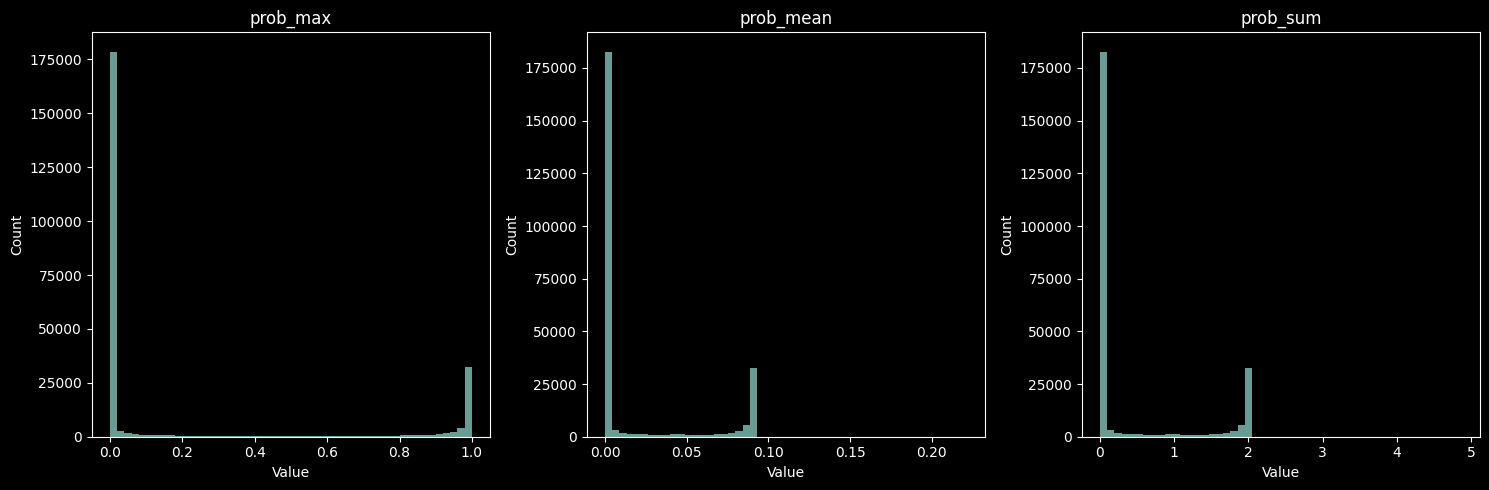

In [9]:
# Add probability summary columns and visualize their distributions
import ast
import numpy as np
import matplotlib.pyplot as plt

def add_prob_statistics(df, prob_col="prob", parse_strings=True,
                        max_col="prob_max", mean_col="prob_mean", sum_col="prob_sum"):
    def to_list(v):
        if isinstance(v, (list, tuple)):
            return [p for p in v if isinstance(p, (int, float))]
        if parse_strings and isinstance(v, str):
            try:
                r = ast.literal_eval(v)
                if isinstance(r, (list, tuple)):
                    return [p for p in r if isinstance(p, (int, float))]
            except Exception:
                return []
        return []
    probs_parsed = df[prob_col].map(to_list)
    df = df.copy()
    df[max_col]  = probs_parsed.map(lambda xs: max(xs) if xs else np.nan)
    df[mean_col] = probs_parsed.map(lambda xs: np.mean(xs) if xs else np.nan)
    df[sum_col]  = probs_parsed.map(lambda xs: np.sum(xs) if xs else np.nan)
    return df

def plot_prob_stats_hist(df, cols=("prob_max", "prob_mean", "prob_sum"), bins=50):
    plt.style.use("dark_background")
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        data = df[col].dropna()
        ax.hist(data, bins=bins, alpha=0.75)
        ax.set_title(col)
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()


all_dfs_with_stats = add_prob_statistics(all_dfs, prob_col="prob")
plot_prob_stats_hist(all_dfs_with_stats)

In [10]:
filtered_df_sum = all_dfs_with_stats[all_dfs_with_stats['prob_sum'] > 2]
filtered_df_sum

,start,end,prob,prob_max,prob_mean,prob_sum
3318,497.55,497.85,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.8636,0.091391,2.0106
6234,934.95,935.25,"[0.2911, 0.0003, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.9939,0.103600,2.2792
1478,1221.55,1221.85,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0005, 0....",0.9994,0.114059,2.5093
5110,1766.35,1766.65,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9927,0.136100,2.9942
6574,1985.95,1986.25,"[0.0, 0.0, 0.0, 0.0198, 0.6994, 0.882, 0.9635,...",0.9635,0.147023,3.2345
...,...,...,...,...,...,...
1364,36204.45,36204.75,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8408, 0.0798,...",0.8704,0.120973,2.6614
1757,36263.40,36263.70,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0002, 0.0853, 0.03...",0.9659,0.093177,2.0499
2654,36397.95,36398.25,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0037, 0.3899,...",0.8133,0.091827,2.0202
2873,36430.80,36431.10,"[0.0003, 0.0, 0.0002, 0.8671, 0.7293, 0.7895, ...",0.8671,0.108695,2.3913


In [11]:
def filter_close_detections(df, distance_threshold=0.2):
    """
    Filter out detections that are close to each other.
    When multiple detections are within distance_threshold, keep only the one with larger start value.
    
    Args:
        df: DataFrame with 'start' column
        distance_threshold: Maximum allowed distance between starts (default 0.2)
        
    Returns:
        DataFrame with filtered rows
    """
    if len(df) <= 1:
        return df
    
    # Sort by start column in descending order (larger values first)
    df_sorted = df.sort_values(by='start', ascending=False).reset_index(drop=True)
    
    # Initialize with first row (largest start value)
    kept_indices = [0]
    last_kept_start = df_sorted.loc[0, 'start']
    
    # Process remaining rows
    for i in range(1, len(df_sorted)):
        current_start = df_sorted.loc[i, 'start']
        
        # If far enough from last kept row, keep this one too
        # Note: Since we're going from larger to smaller, the comparison is flipped
        if last_kept_start - current_start >= distance_threshold:
            kept_indices.append(i)
            last_kept_start = current_start
    
    # Return dataframe with only kept rows
    return df_sorted.loc[kept_indices].reset_index(drop=True)

# Example usage
filtered_df_deduped = filter_close_detections(filtered_df_sum)
print(f"Original detections: {len(filtered_df_sum)}")
print(f"After deduplication: {len(filtered_df_deduped)}")

Original detections: 304
After deduplication: 278


In [12]:
import sys
import os

# Add parent directory to path (adjust as needed)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added {project_root} to Python path")
    
from rnd.utils.data_utils import (
    extract_arm_angles,
    create_arm_array,
)
from ilipy import Session
from ilipy.database import DistanceCorrelation


root_dir = f"./data/fhr{run_number}"
os.makedirs(root_dir, exist_ok=True)

session = Session(environment=environment)
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

def gen_image(img_start, session, dist_corr, length= 0.3, show_im=True, normalize="range"):
    img_range = (img_start, img_start + length)
    tick_sampling_interval = 10

    arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
    num_tick_samples = int(length * 10000 / tick_sampling_interval)
    img = create_arm_array(
    arm_angles,
    num_tracks=num_tracks,
    num_tick_samples=num_tick_samples,
    normalize=normalize,
)
    if show_im: 
        plt.imshow(
            img.T, cmap="inferno", origin="lower", aspect="auto",
            interpolation="nearest",
        )

        plt.axis("off")
        plt.show()
    return img


Added /home/zmirikha/GitHub/rnd_q2 to Python path
PySettings.cpp(46): ilipy: Build 0.18.0.12150 f0baf65fb3 release-ili-0.18 'Tue Oct 21 19:59:39 2025'
PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/defaults.json
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/prod.json
PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
CognitoAuthenticator.cpp(883): Logged in as username: zahra.

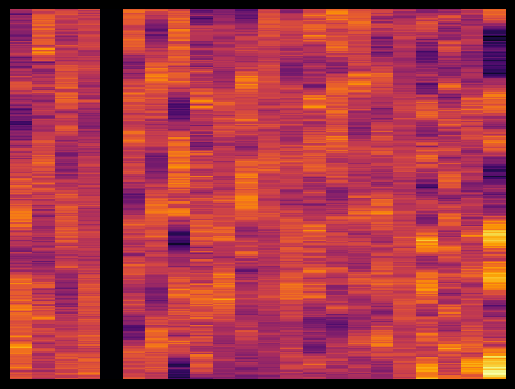

0
36580.50000000563 [0.0, 0.0, 0.0, 0.0, 0.0003, 0.8664, 0.9997, 0.9955, 1e-04, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


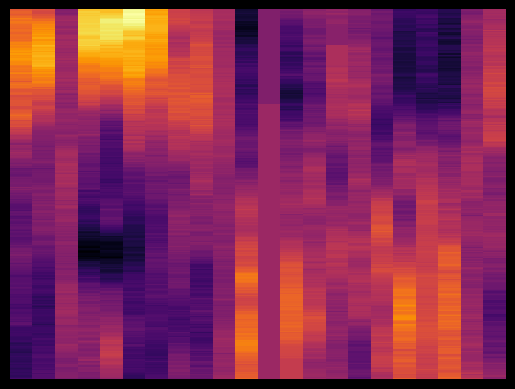

1
36430.95000000418 [0.0003, 0.0, 0.0002, 0.8671, 0.7293, 0.7895, 0.003, 1e-04, 0.0002, 0.0, 0.0, 0.0, 0.0, 0.0, 1e-04, 1e-04, 0.0013, 1e-04, 0.0, 0.0, 0.0, 0.0]


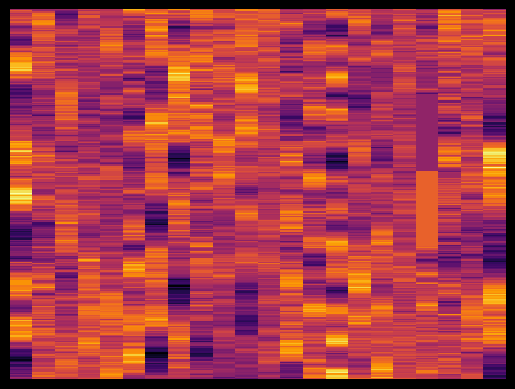

2
36398.10000000386 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0037, 0.3899, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8133, 0.8133]


KeyboardInterrupt: 

In [13]:
for i, row in filtered_df_deduped.iterrows():
    vd = (row['start']+ row['end'])/2
    img_std = gen_image(row['start'], session, dist_corr, length=0.3, show_im=True, normalize="std")
    print(i)
    print(vd, row['prob'])

Collected 55497 index positions (prob >= 0.99).


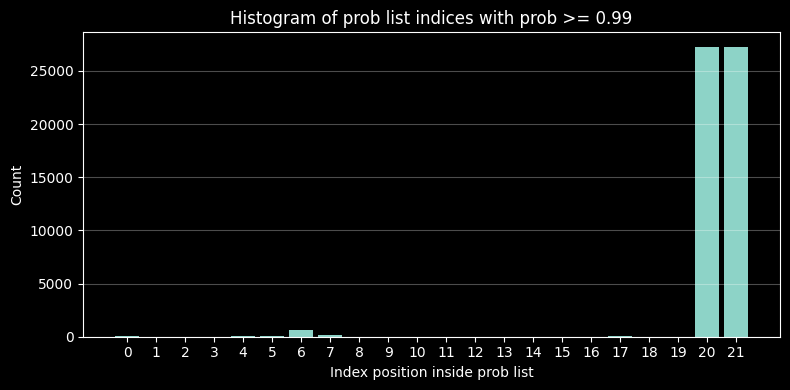

,count
0,41
1,17
3,12
4,32
5,26
6,631
7,130
8,1
9,2
10,6


In [14]:
# From the whole dataframe: collect positions (indices) inside each prob list whose value >= threshold
# and plot a histogram of those index positions.

import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_prob_list(v):
    if isinstance(v, (list, tuple)):
        return [p for p in v if isinstance(p, (int, float))]
    if isinstance(v, str):
        try:
            r = ast.literal_eval(v)
            if isinstance(r, (list, tuple)):
                return [p for p in r if isinstance(p, (int, float))]
        except Exception:
            return []
    return []

def collect_prob_arg_indices(df, threshold, prob_col="prob", parse_strings=True):
    """
    Returns a flat list of index positions (0-based) in each probability list
    whose probability >= threshold.
    """
    arg_positions = []
    for probs_raw in df[prob_col]:
        probs = parse_prob_list(probs_raw) if parse_strings else probs_raw
        for idx, p in enumerate(probs):
            if p >= threshold:
                arg_positions.append(idx)
    return arg_positions

def plot_arg_index_hist(arg_positions, threshold, bins=None):
    if not arg_positions:
        print("No positions found for given threshold.")
        return
    max_idx = max(arg_positions)
    if bins is None:
        bins = np.arange(0, max_idx + 2) - 0.5  # bar for each integer index
    plt.style.use("dark_background")
    plt.figure(figsize=(8,4))
    plt.hist(arg_positions, bins=bins, rwidth=0.85)
    plt.xlabel("Index position inside prob list")
    plt.ylabel("Count")
    plt.title(f"Histogram of prob list indices with prob >= {threshold}")
    plt.xticks(range(0, max_idx+1))
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example usage:
threshold_for_args = 0.99
arg_pos = collect_prob_arg_indices(all_dfs, threshold=threshold_for_args, prob_col="prob")
print(f"Collected {len(arg_pos)} index positions (prob >= {threshold_for_args}).")
plot_arg_index_hist(arg_pos, threshold_for_args)

# If you want a frequency table:
arg_freq = pd.Series(arg_pos).value_counts().sort_index()
display(arg_freq.to_frame(name="count"))

In [15]:
# Create filtered DataFrame: rows whose max prob >= threshold AND argmax NOT in excluded indices.
import ast
import numpy as np
import pandas as pd

def parse_prob_list_safe(v):
    if isinstance(v, (list, tuple)):
        return [p for p in v if isinstance(p, (int, float))]
    if isinstance(v, str):
        try:
            r = ast.literal_eval(v)
            if isinstance(r, (list, tuple)):
                return [p for p in r if isinstance(p, (int, float))]
        except Exception:
            return []
    return []

def filter_by_max_prob_excluding_indices(df, prob_col="prob", threshold=0.9,
                                         excluded_indices=(6,7,20,21,17,0),
                                         max_col="prob_max", argmax_col="prob_argmax"):
    probs = df[prob_col].map(parse_prob_list_safe)
    max_vals = probs.map(lambda xs: max(xs) if xs else np.nan)
    
    # Check if ALL indices with prob >= threshold are in excluded_indices
    def has_valid_high_prob_indices(xs):
        if not xs:
            return False
        high_prob_indices = [i for i, p in enumerate(xs) if p >= threshold]
        if not high_prob_indices:
            return False
        # Return True if at least one high-prob index is NOT in excluded_indices
        return any(i not in excluded_indices for i in high_prob_indices)
    
    valid_mask = probs.map(has_valid_high_prob_indices)
    argmax_vals = probs.map(lambda xs: int(np.argmax(xs)) if xs else np.nan)
    
    out = df.copy()
    out[max_col] = max_vals
    out[argmax_col] = argmax_vals
    
    # Filter: max prob >= threshold AND at least one high-prob index is not excluded
    mask = (out[max_col] >= threshold) & valid_mask
    return out[mask].reset_index(drop=True)

# Example usage:
threshold_val = 0.99
filtered_df_excl = filter_close_detections(filter_by_max_prob_excluding_indices(all_dfs, prob_col="prob", threshold=threshold_val))
print(f"Filtered rows: {len(filtered_df_excl)} (threshold={threshold_val}, excluded indices = (6,7,20,21))")

Filtered rows: 97 (threshold=0.99, excluded indices = (6,7,20,21))


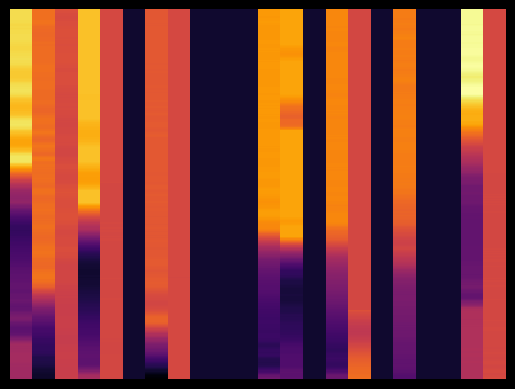

0
36863.85000000838 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0003, 0.0, 1e-04, 0.9902, 0.0004, 0.0002, 0.93, 0.0, 0.0, 0.0, 0.0]


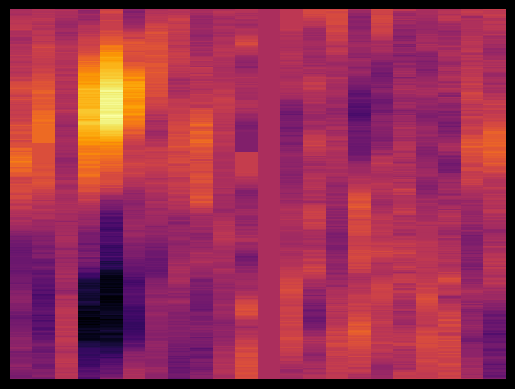

1
36430.65000000418 [0.0, 0.0, 0.0239, 0.9978, 0.3366, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


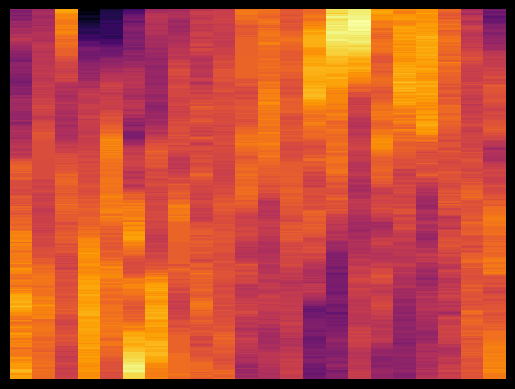

2
36429.450000004166 [0.0, 0.0, 0.0003, 0.8994, 0.9986, 0.0004, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


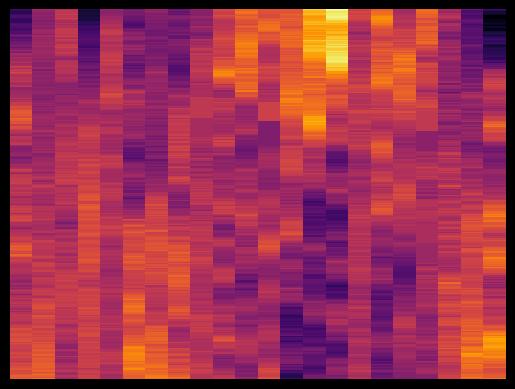

3
36401.55000000389 [1e-04, 0.0002, 0.0131, 0.9965, 0.2648, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0002, 0.0002]


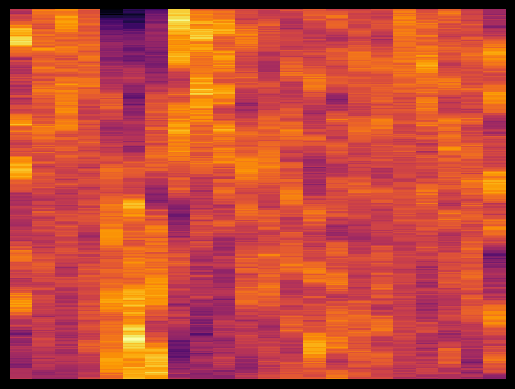

4
36276.750000002685 [0.0, 0.0, 0.0, 0.0, 0.9987, 0.0037, 0.0, 0.0005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


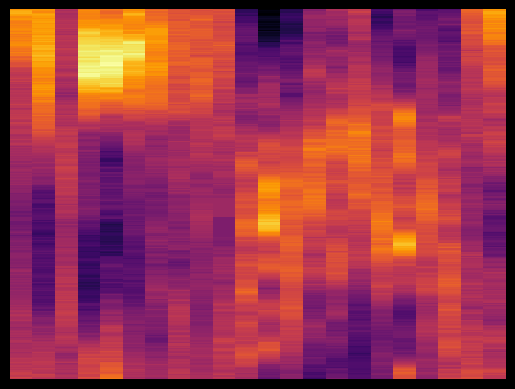

5
36272.25000000264 [0.0, 0.0, 0.0, 0.0151, 0.9938, 0.0366, 0.0, 1e-04, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


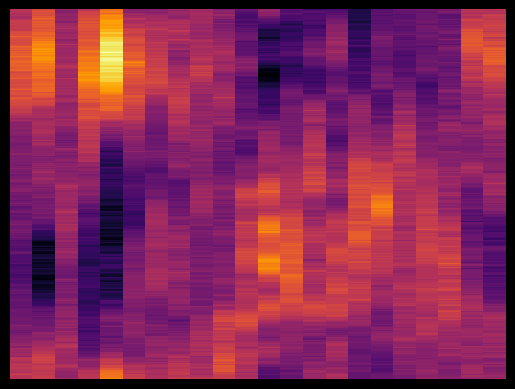

6
36271.65000000264 [0.0028, 0.002, 0.0007, 0.9913, 0.0072, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


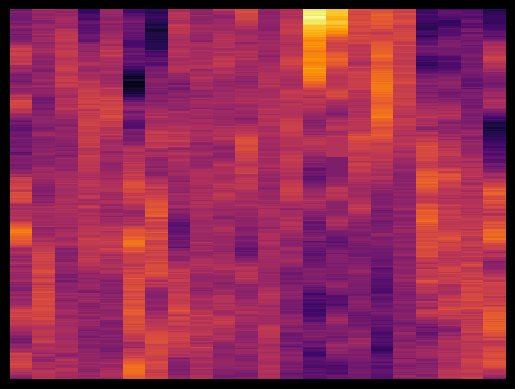

7
36270.15000000262 [0.0, 0.0, 1e-04, 1e-04, 0.9994, 0.9869, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


KeyboardInterrupt: 

In [16]:
for i, row in filtered_df_excl.iterrows():
    vd = (row['start']+ row['end'])/2
    img_std = gen_image(row['start'], session, dist_corr, length=0.3, show_im=True, normalize="std")
    print(i)
    print(vd, row['prob'])

In [19]:
filtered_df_excl

,start,end,prob,prob_max,prob_argmax
0,36863.70,36864.00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9902,14
1,36430.50,36430.80,"[0.0, 0.0, 0.0239, 0.9978, 0.3366, 0.0, 0.0, 0...",0.9978,3
2,36429.30,36429.60,"[0.0, 0.0, 0.0003, 0.8994, 0.9986, 0.0004, 0.0...",0.9986,4
3,36401.40,36401.70,"[1e-04, 0.0002, 0.0131, 0.9965, 0.2648, 0.0, 0...",0.9965,3
4,36276.60,36276.90,"[0.0, 0.0, 0.0, 0.0, 0.9987, 0.0037, 0.0, 0.00...",0.9987,4
...,...,...,...,...,...
92,2016.50,2016.80,"[0.0, 0.0, 0.0, 0.0, 0.9693, 0.9985, 0.2355, 0...",0.9985,5
93,1766.35,1766.65,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9927,11
94,1237.15,1237.45,"[0.0, 0.0, 0.0, 0.9974, 0.0521, 0.0, 0.0, 0.0,...",0.9974,3
95,1221.55,1221.85,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0005, 0....",0.9994,8


In [ ]:
import boto3
import pandas as pd
from io import BytesIO

def save_df_to_s3_parquet(df, bucket_name, s3_key):
    """
    Save DataFrame to S3 as parquet file
    
    Args:
        df: DataFrame to save
        bucket_name: S3 bucket name
        s3_key: S3 key (path) for the file
    """
    # Convert DataFrame to parquet in memory
    parquet_buffer = BytesIO()
    df.to_parquet(parquet_buffer, index=False)
    parquet_buffer.seek(0)
    
    # Upload to S3
    s3_client = boto3.client('s3')
    s3_client.put_object(
        Bucket=bucket_name,
        Key=s3_key,
        Body=parquet_buffer.getvalue(),
        ContentType='application/octet-stream'
    )
    
    print(f"DataFrame saved to s3://{bucket_name}/{s3_key}")

    
    

In [22]:
bucket_name = "dent-dev"
s3_key = f"dent_bookmarks/ArmDent_bookmarks_{inspection_id}.parquet"

save_df_to_s3_parquet(filtered_df_excl, bucket_name, s3_key)

DataFrame saved to s3://dent-dev/dent_bookmarks/ArmDent_bookmarks_0A1OLRV96N3.parquet


DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy


In [ ]:
from __future__ import annotations

from ilipy import Session
from ilipy.channeldata import ImageProfile
from ilipy.features import Bookmarks

from ilipyutils.ml_features.base import (
    AnomalyStatus,
    get_ml_models_info_list,
)
from ilipyutils.ml_features.insert import FeatureInsert,GeometryCubeParameters
from ilipy import ClipTypes, TrackIndex, ViewDistance

session = Session(environment=environment)
bookmarks_interface = Bookmarks(connector=session.database_connector)

feature_insert = FeatureInsert(session=session, bookmarks_interface=bookmarks_interface)

PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
HttpRequestPool.cpp(82): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8080, Concurrent Connections: 1
HttpRequestPool.cpp(82): [HttpRequestPool] Host: storage-dvh-01.darkvision.local, Port: 8080, Concurrent Connections: 1
RestApi.cpp(72): ApiService Ping Response (http://storage-dvv-01.darkvision.local:8080) : 200, 12ms
RestApi.cpp(72): ApiService Ping Response (http://storage-dvh-01.darkvision.local:8080) : 200, 143ms


DbHealthCheck.cpp(146): Database service health check complete: Healthy


In [18]:
anomalies = bookmarks_interface.get_anomalies(inspectionId="0A1OLRV96N3")
dent_anomalies = [a for a in anomalies if "Dent-Detection-v3" in a.tags]
len(dent_anomalies)


127

In [ ]:



# feature_insert._construct_geometry

# geometry: GeometryBase = feature_insert._construct_geometry(
#     tlbr_track_indices=tlbr_track_indices,
#     tlbr_odometer_ticks=tlbr_odometer_ticks,
#     cube_params=cube_params,
# )

# anomaly_info_ilipy.feature.geometry = geometry


GeometryBoundingCube(track_index=4, image_profile=ZeroAngle, top_left=GeometryCubePoint(trackIndex=4, radialPositionMm=1, cubeAngleRad=-0.215954, probeScanAngleRad=-0.261799, odometerTicks=34552728), bottom_right=GeometryCubePoint(trackIndex=5, radialPositionMm=1, cubeAngleRad=-0.215954, probeScanAngleRad=0.261799, odometerTicks=34555729))


/tmp/ipykernel_621218/110920444.py:1: DeprecationWarning: AnomalyInfo.geometry is deprecated, use AnomalyInfo.feature.geometry instead.
  print(dent_anomalies[0].geometry)


GeometryCubePoint(track_index=5, radial_position_mm=1, cube_angle_rad=-0.21595433354377747, probe_scan_angle_rad=0.2617993950843811, odometer_ticks=34555729)

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: 

In [ ]:
#_ = [bookmarks_interface.delete_anomaly(a.feature.anomaly_feature_id) for a in dent_anomalies]

In [ ]:
get_ml_models_info_list()

In [ ]:
model_info = next(
    model
    for model in get_ml_models_info_list()
    if model.model_name == "Dent-Detection-v3"
)
model_info


In [ ]:
from ili_custom_data.load_model import ModelDataLoader

latest_model = ModelDataLoader.get_latest_model()

In [ ]:
session = Session(environment=environment)
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)
clips = session.get_clips_by_type(ClipTypes.ChannelData)

In [ ]:
def get_decimal_range(value):
    """
    For a number like 0.56, return (0.5, 0.6)
    For a number like 0.78, return (0.7, 0.8)
    
    Args:
        value (float): A decimal value 
        
    Returns:
        tuple: The lower and upper bounds of the decimal range
    """
    # Get the first decimal place as the lower bound
    lower = int(value * 100) / 100
    # The upper bound is just 0.01 more
    upper = round(lower + 0.01, 2)

    return lower, upper

In [ ]:

cube_params = GeometryCubeParameters(
tlbr_cube_angle_rad=(np.deg2rad(-15), np.deg2rad(-15)),
tlbr_probe_scan_angle_rad=(np.deg2rad(-15), np.deg2rad(15)),
tlbr_radial_position_mm=(1, 1),
)


In [ ]:
for i, row in filtered_df_excl.iterrows():
        print(i)

    
        profile = ImageProfile.ZeroAngle 
        vd_start, vd_end, probs_raw = row['start'], row['end'], row['prob']
        probs = parse_prob_list_safe(probs_raw)
        arg_max_probs = [idx for idx, p in enumerate(probs) if p >= 0.99]
        if i!=0:
              
            for arg_max_prob in arg_max_probs:
                track_nums = (arg_max_prob,arg_max_prob)
                bookmark_conf_score = probs[arg_max_prob]
                start_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(track_nums[0]), ViewDistance(vd_start)).value
                end_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(track_nums[1]), ViewDistance(vd_end)).value
                model_instance = latest_model(
                ml_confidence_score=bookmark_conf_score,)
                lower_bound, upper_bound = get_decimal_range(bookmark_conf_score)
                extra_tags = {f"threshold_bin-{lower_bound}-{upper_bound}"}
                model_instance = latest_model(
                ml_confidence_score=bookmark_conf_score,)

                # anomaly_info = feature_insert.insert_ml_pred(
                # inspection_id=inspection_id,
                # tlbr_track_indices=track_nums,
                # tlbr_odometer_ticks=(start_frame_odo_ticks, end_frame_odo_ticks),
                # cube_params=cube_params,
                # model_info=model_info,
                # anomaly_status=AnomalyStatus.REVIEW_DETECTION,
                # image_profile=profile,
                # extra_tags=extra_tags,
                # ili_custom_data=model_instance
                # )


In [ ]:
anomaly_info